# Output formats and performance

What `fig.save(...)` actually writes, what each format guarantees, and how long
it takes. The two halves belong together: the guarantees are the reason the
library exists, and the speed is what makes them free.

The benchmark section at the end needs matplotlib (`pip install matplotlib`);
everything before it needs nothing.

> **The timings below were measured on the machine that built this notebook**
> and will differ on yours — re-run the cells to get your own. The *shape* of
> the result is what travels.

In [1]:
import math
import os
import random
import re
import subprocess
import sys
import tempfile
import time
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import pyplotrs as plt

plt.set_font_family("Liberation Sans")
random.seed(5)

OUT = Path(tempfile.mkdtemp(prefix="pyplotrs-output-"))

t = [i * 0.05 for i in range(241)]
wave = [math.sin(x) * math.exp(-0.1 * x) for x in t]


def figure():
    """One representative figure: text, math, a legend, a curve."""
    fig, ax = plt.subplots(figsize=(260, 190))
    ax.line(t, wave, label=r"$e^{-\gamma t}\sin\omega t$")
    ax.fill_between(t, [y - 0.05 for y in wave], [y + 0.05 for y in wave],
                    alpha=0.2)
    ax.legend()
    ax.set(title="Damped oscillation", xlabel=r"time $t$ (s)",
           ylabel=r"amplitude (mV)")
    return fig


def kb(path):
    return f"{Path(path).stat().st_size / 1024:.1f} KB"


print("pyplotrs", plt.__version__)

pyplotrs 0.1.0


## One call, five formats

The extension picks the writer. Nothing else in the call changes.

figure.pdf       21.0 KB
figure.svg     2525.3 KB
figure.png       34.9 KB
figure.html    2770.7 KB
hires.png       130.9 KB   (dpi=600)
clear.png        36.0 KB   (transparent=True)


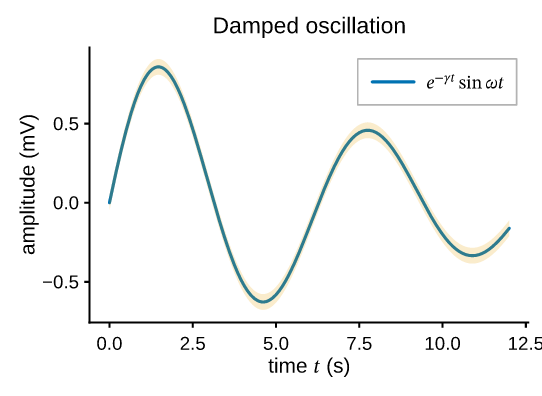

In [2]:
fig = figure()
for name in ("figure.pdf", "figure.svg", "figure.png", "figure.html"):
    fig.save(str(OUT / name))
    print(f"{name:<14}{kb(OUT / name):>10}")

fig.save(str(OUT / "hires.png"), dpi=600)
fig.save(str(OUT / "clear.png"), transparent=True)
print(f"{'hires.png':<14}{kb(OUT / 'hires.png'):>10}   (dpi=600)")
print(f"{'clear.png':<14}{kb(OUT / 'clear.png'):>10}   (transparent=True)")
fig

| Format | What it guarantees |
|---|---|
| `.pdf` | Embedded, subset CID-keyed TrueType. Text stays selectable, extractable and re-typeable; `tagged=True` adds an accessibility structure tree. |
| `.svg` | Real `<text>` elements with the font embedded, so it renders identically anywhere without the reader having the face. |
| `.png` | 8-bit RGBA at any `dpi`, with physical-size metadata, optional transparency, and multi-threaded encoding. |
| `.html` | One self-contained page — font, styles and any math inlined. Fetches nothing when opened. 3D figures get an interactive viewer. |
| `.gif` / `.apng` | Animation output, from `Animation.save`. |

## The PDF claim, checked

The project's headline claim is that a saved PDF keeps **real text**. That is
not a matter of taste — it is a structural property of the file, and you can
check it here without leaving the notebook or installing a PDF tool. Font
descriptors live outside the compressed content streams, so a substring search
is enough.

In [3]:
pdf = (OUT / "figure.pdf").read_bytes()

checks = [
    ("no Type 3 glyph procedures", b"/Type3" not in pdf and b"/CharProcs" not in pdf),
    ("CID-keyed TrueType",         b"CIDFontType2" in pdf),
    ("the font file is embedded",  b"/FontFile2" in pdf),
    ("Identity-H encoding",        b"/Identity-H" in pdf),
    ("a ToUnicode map (so text extracts)", b"/ToUnicode" in pdf),
]
for label, passed in checks:
    print(f"  {'✓' if passed else '✗'}  {label}")

  ✓  no Type 3 glyph procedures
  ✓  CID-keyed TrueType
  ✓  the font file is embedded
  ✓  Identity-H encoding
  ✓  a ToUnicode map (so text extracts)


Type 3 is the one that matters. It is a font made of drawing procedures rather
than glyphs, it is what matplotlib's PDF backend emits by default, and IEEE, ACM
and several publisher preflight systems reject it outright. A pyplotrs PDF never
contains one — the same figure opens in Illustrator with every label
selectable, re-typeable and restylable.

### Accessible, tagged PDF

`tagged=True` adds a structure tree, a document title, a language, and alt text
for the figure — what a screen reader and a compliance checker look for.

In [4]:
fig.save(str(OUT / "tagged.pdf"), tagged=True, title="Figure 2",
         alt="Damped oscillation of amplitude against time, with a "
             "confidence band.")

tagged = (OUT / "tagged.pdf").read_bytes()
for label, marker in [("structure tree", b"/StructTreeRoot"),
                      ("marked content", b"/MarkInfo"),
                      ("document language", b"/Lang"),
                      ("alt text", b"/Alt")]:
    print(f"  {'✓' if marker in tagged else '✗'}  {label}")
print(f"\n  plain {kb(OUT / 'figure.pdf')} → tagged {kb(OUT / 'tagged.pdf')}")

  ✓  structure tree
  ✓  marked content
  ✓  document language
  ✓  alt text

  plain 21.0 KB → tagged 21.9 KB


## SVG and HTML

The SVG keeps text as `<text>` and embeds the font, so the file is both
editable and self-contained. The HTML inlines everything — open it on a machine
with no network and it renders identically.

That self-containment is the whole of the file size. A vector figure's geometry
is a few kilobytes; the rest is the embedded font, and a `$…$` label pulls in
the math face on top of the body face:

In [5]:
svg = (OUT / "figure.svg").read_text()
labels = re.findall(r"<text[^>]*>([^<]*)</text>", svg)
print(f"SVG: {len(labels)} <text> elements — {labels[:6]} …")
print(f"     font embedded: {'@font-face' in svg or 'base64' in svg}")

html = (OUT / "figure.html").read_text()
remote = re.findall(r'<(?:script|link|img)[^>]*(?:src|href)="https?://[^"]*"', html)
print(f"HTML: {len(html) / 1024:.0f} KB, {len(remote)} resources fetched on open")

# Self-contained has a price, and it is worth knowing where it lands. The
# figure above carries a $…$ label, so it embeds the math face as well as the
# body face; the same figure without math embeds only one.
plain, ax = plt.subplots(figsize=(260, 190))
ax.line(t, wave, label="damped")
ax.legend()
ax.set(title="Damped oscillation", xlabel="time (s)", ylabel="amplitude (mV)")
plain.save(str(OUT / "plain.svg"))
plain.save(str(OUT / "plain.html"))
print("\n            with math    without math")
for ext in ("svg", "html"):
    print(f"  .{ext:<8}{kb(OUT / f'figure.{ext}'):>10}{kb(OUT / f'plain.{ext}'):>15}")

SVG: 23 <text> elements — ['0.0', '2.5', '5.0', '7.5', '10.0', '12.5'] …
     font embedded: True
HTML: 2771 KB, 0 resources fetched on open

            with math    without math
  .svg      2525.3 KB       540.0 KB
  .html     2770.7 KB       540.5 KB


surface.html    597.1 KB
surface.pdf      24.6 KB
surface.svg     600.6 KB


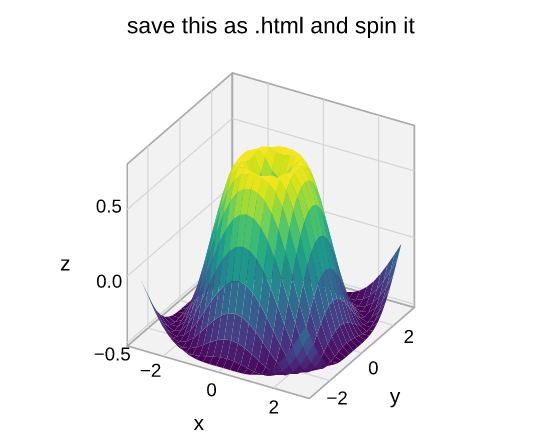

In [6]:
# 3D figures save to HTML as an interactive Canvas2D viewer you can spin -
# and to PDF/SVG as editable vector paths, not a rasterized inset.
S = 25
gx = [[-3.0 + 6.0 * j / (S - 1) for j in range(S)] for _ in range(S)]
gy = [[-3.0 + 6.0 * i / (S - 1) for _ in range(S)] for i in range(S)]
gz = [[math.sin(math.hypot(x, y) * 1.5) * math.exp(-0.25 * math.hypot(x, y))
       for x, y in zip(rx, ry)] for rx, ry in zip(gx, gy)]

surface = plt.figure(figsize=(260, 210))
ax3d = surface.add_subplot(surface.add_gridspec(1, 1)[0, 0], projection="3d")
ax3d.surface(gx, gy, gz, cmap="viridis")
ax3d.set(title="save this as .html and spin it", xlabel="x", ylabel="y",
         zlabel="z")

for name in ("surface.html", "surface.pdf", "surface.svg"):
    surface.save(str(OUT / name))
    print(f"{name:<14}{kb(OUT / name):>10}")
surface

## Animation

`animate(render, frames)` calls `render(i)` for each frame and expects a
`Figure` back — every frame is an ordinary figure, built the ordinary way. The
extension on `save` picks GIF (256 colors, viewable anywhere) or APNG (full
color).

24 frames → 53.6 KB


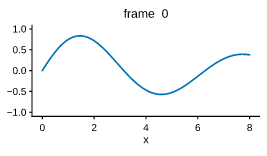

In [7]:
from IPython.display import Image

xs = [i * 0.08 for i in range(101)]


def frame(i):
    """A traveling wave: frame i is the same plot, phase-shifted."""
    phase = 2 * math.pi * i / 24
    fig, ax = plt.subplots(figsize=(240, 140))
    ax.line(xs, [math.sin(x - phase) * math.exp(-0.12 * x) for x in xs])
    ax.set(title=f"frame {i:2d}", xlabel="x", ylim=(-1.1, 1.1))
    return fig


animation = plt.animate(frame, 24, fps=12)
animation.save(str(OUT / "wave.gif"), dpi=80)
print(f"{len(animation)} frames → {kb(OUT / 'wave.gif')}")

Image(data=(OUT / "wave.gif").read_bytes(), format="gif")

## Threads

Rendering releases the GIL. A `ThreadPoolExecutor` over figures therefore
actually runs in parallel, which is the usual shape of a batch job: one figure
per subject, per run, per parameter setting.

The measurement below builds the figures first and times only `save()`, because
that is the part the claim is about — building a figure is ordinary Python and
holds the GIL like any other Python.

In [8]:
random.seed(8)
POINTS = 40_000
cloud_x = [random.gauss(0, 1) for _ in range(POINTS)]
cloud_y = [random.gauss(0, 1) for _ in range(POINTS)]

JOBS = 12
workers = min(8, os.cpu_count() or 1)


def build(i):
    """An export-heavy figure: 40k markers is real work for the renderer."""
    fig, ax = plt.subplots(figsize=(420, 320))
    ax.scatter(cloud_x, cloud_y, markersize=2, alpha=0.5)
    ax.set(title=f"batch item {i}", xlabel="x", ylabel="y")
    return fig


print(f"{JOBS} figures × {POINTS:,} points, {workers} worker threads "
      f"on {os.cpu_count()} cores\n")
print(f"{'format':<8}{'serial':>9}{'threaded':>10}{'speedup':>9}")
for ext in ("pdf", "svg", "png"):
    figures = [build(i) for i in range(JOBS)]
    figures[0].save(str(OUT / f"warm.{ext}"), dpi=200)      # warm the caches

    start = time.perf_counter()
    for i, figure_i in enumerate(figures):
        figure_i.save(str(OUT / f"serial_{i}.{ext}"), dpi=200)
    serial = time.perf_counter() - start

    figures = [build(i) for i in range(JOBS)]               # a fresh set
    start = time.perf_counter()
    with ThreadPoolExecutor(max_workers=workers) as pool:
        list(pool.map(lambda pair, ext=ext: pair[1].save(
            str(OUT / f"threaded_{pair[0]}.{ext}"), dpi=200), enumerate(figures)))
    threaded = time.perf_counter() - start

    print(f".{ext:<7}{serial:>8.2f}s{threaded:>9.2f}s{serial / threaded:>8.1f}×")

12 figures × 40,000 points, 8 worker threads on 20 cores

format     serial  threaded  speedup


.pdf        0.28s     0.06s     4.9×


.svg        0.12s     0.05s     2.6×


.png        0.16s     0.11s     1.5×


The vector formats show the effect most clearly. **PNG shows less, and that is
not a disappointment** — raster export is already multi-threaded inside the
library (the canvas is split into horizontal bands, and scanline filtering and
DEFLATE both run in parallel), so the serial baseline is already using the
machine. Threading it again mostly moves the same work around.

## Against matplotlib

Everything from here needs matplotlib. The comparison is like for like: the same
data, the same figure size, the same dpi, and the same output file, timed as
best-of-three after a warm-up.

Two things the numbers do *not* say, and should:

- **The timed region is not symmetric.** In pyplotrs a mark call only records
  the mark; layout, shaping and rendering all happen inside `save()`. matplotlib
  has built its artists before the timer starts. So this measures "time to get a
  file from data you already have", which is the thing that matters to a batch
  job, but it is not "time spent in the renderer".
- **Import time is outside every row below**, and it is the largest single
  number on the page.

In [9]:
import matplotlib
import matplotlib.pyplot as mpl

mpl.rcParams["figure.dpi"] = 100
mpl.rcParams["savefig.dpi"] = 100
DPI, SIZE_PT = 100, (300, 220)
INCHES = (SIZE_PT[0] / 72, SIZE_PT[1] / 72)

print("matplotlib", matplotlib.__version__)


def best_of(fn, repeat=2):
    """Best of `repeat` runs, after one untimed warm-up."""
    fn()
    times = []
    for _ in range(repeat):
        start = time.perf_counter()
        fn()
        times.append(time.perf_counter() - start)
    return min(times)

matplotlib 3.11.0


In [10]:
# Import cost, measured in a fresh interpreter each time - the only honest way
# to time an import.
def import_seconds(module):
    code = (f"import time; s=time.perf_counter(); import {module}; "
            "print(time.perf_counter()-s)")
    best = min(float(subprocess.run([sys.executable, "-c", code],
                                    capture_output=True, text=True,
                                    check=True).stdout)
               for _ in range(3))
    return best


pp_import = import_seconds("pyplotrs")
mpl_import = import_seconds("matplotlib.pyplot")
print(f"import pyplotrs           {pp_import * 1000:7.1f} ms")
print(f"import matplotlib.pyplot  {mpl_import * 1000:7.1f} ms"
      f"   ({mpl_import / pp_import:.0f}× longer)")

import pyplotrs              27.3 ms
import matplotlib.pyplot    262.6 ms   (10× longer)


In [11]:
# A dense line, a scatter, and a nine-panel grid, each written to each format.
N = 50_000
line_x = [i / N * 10 for i in range(N)]
line_y = [math.sin(x) * math.exp(-0.05 * x) for x in line_x]

M = 20_000
pts_x = [random.gauss(0, 1) for _ in range(M)]
pts_y = [random.gauss(0, 1) for _ in range(M)]

results = []


def record(case, fmt, pp_time, mpl_time, pp_path, mpl_path):
    results.append({"case": case, "format": fmt, "pp": pp_time, "mpl": mpl_time,
                    "pp_size": Path(pp_path).stat().st_size,
                    "mpl_size": Path(mpl_path).stat().st_size})


for fmt in ("pdf", "svg", "png"):
    # --- a 50k-point line ------------------------------------------------
    def save_pp_line(fmt=fmt):
        fig, ax = plt.subplots(figsize=SIZE_PT)
        ax.line(line_x, line_y)
        fig.save(str(OUT / f"bench_line_pp.{fmt}"), dpi=DPI)

    def save_mpl_line(fmt=fmt):
        fig, ax = mpl.subplots(figsize=INCHES)
        ax.plot(line_x, line_y)
        fig.savefig(OUT / f"bench_line_mpl.{fmt}", dpi=DPI)
        mpl.close(fig)

    record("line 50k", fmt, best_of(save_pp_line), best_of(save_mpl_line),
           OUT / f"bench_line_pp.{fmt}", OUT / f"bench_line_mpl.{fmt}")

    # --- a 20k-point scatter ----------------------------------------------
    def save_pp_scatter(fmt=fmt):
        fig, ax = plt.subplots(figsize=SIZE_PT)
        ax.scatter(pts_x, pts_y, markersize=2)
        fig.save(str(OUT / f"bench_scatter_pp.{fmt}"), dpi=DPI)

    def save_mpl_scatter(fmt=fmt):
        fig, ax = mpl.subplots(figsize=INCHES)
        ax.scatter(pts_x, pts_y, s=4)
        fig.savefig(OUT / f"bench_scatter_mpl.{fmt}", dpi=DPI)
        mpl.close(fig)

    record("scatter 20k", fmt, best_of(save_pp_scatter),
           best_of(save_mpl_scatter),
           OUT / f"bench_scatter_pp.{fmt}", OUT / f"bench_scatter_mpl.{fmt}")

    # --- nine panels ------------------------------------------------------
    def save_pp_panels(fmt=fmt):
        fig, axs = plt.subplots(3, 3, figsize=(600, 440))
        for row in axs:
            for ax in row:
                ax.line(line_x[:5000], line_y[:5000])
                ax.set(xlabel="t", ylabel="y")
        fig.save(str(OUT / f"bench_panels_pp.{fmt}"), dpi=DPI)

    def save_mpl_panels(fmt=fmt):
        fig, axs = mpl.subplots(3, 3, figsize=(600 / 72, 440 / 72))
        for row in axs:
            for ax in row:
                ax.plot(line_x[:5000], line_y[:5000])
                ax.set(xlabel="t", ylabel="y")
        fig.savefig(OUT / f"bench_panels_mpl.{fmt}", dpi=DPI)
        mpl.close(fig)

    record("9 panels", fmt, best_of(save_pp_panels), best_of(save_mpl_panels),
           OUT / f"bench_panels_pp.{fmt}", OUT / f"bench_panels_mpl.{fmt}")

print(f"{'case':<16}{'fmt':<6}{'pyplotrs':>10}{'matplotlib':>12}{'speedup':>9}"
      f"{'pp size':>10}{'mpl size':>10}")
for r in results:
    print(f"{r['case']:<16}{r['format']:<6}{r['pp'] * 1000:>9.1f}ms"
          f"{r['mpl'] * 1000:>11.1f}ms{r['mpl'] / r['pp']:>8.1f}×"
          f"{r['pp_size'] / 1024:>9.0f}K{r['mpl_size'] / 1024:>9.0f}K")

case            fmt     pyplotrs  matplotlib  speedup   pp size  mpl size
line 50k        pdf         4.2ms       24.2ms     5.7×        8K        8K
scatter 20k     pdf        13.1ms      180.6ms    13.8×      216K      302K
9 panels        pdf         6.2ms      114.3ms    18.6×       11K        8K
line 50k        svg         4.6ms       23.4ms     5.1×      539K       16K
scatter 20k     svg         6.7ms      175.7ms    26.3×     1466K     2088K
9 panels        svg         6.2ms      110.1ms    17.6×      565K       57K
line 50k        png         5.2ms       29.0ms     5.5×        9K       18K
scatter 20k     png         7.8ms       58.2ms     7.5×       64K       23K
9 panels        png         9.7ms      134.2ms    13.9×       35K       66K


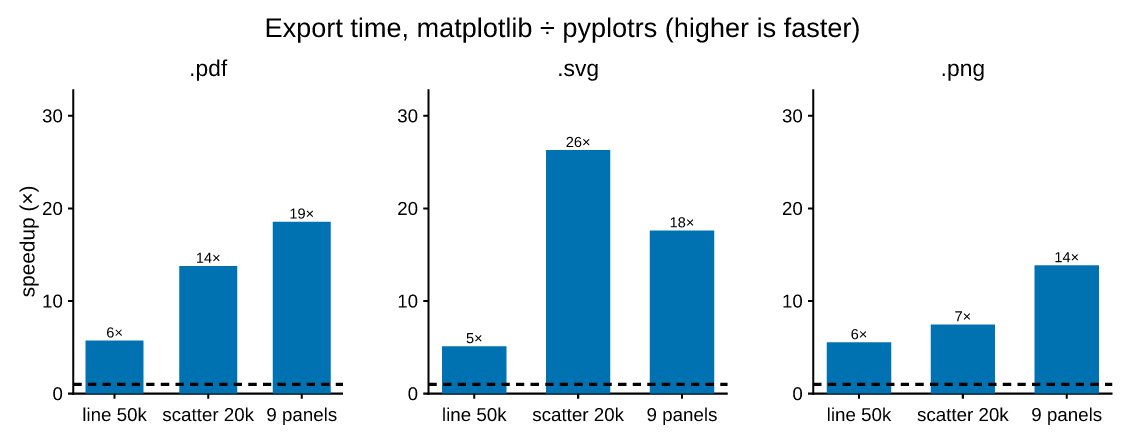

In [12]:
# The same table as a chart, drawn with pyplotrs: one panel per format, one bar
# per case, so nothing has to be read sideways.
formats = ["pdf", "svg", "png"]
cases = [r["case"] for r in results if r["format"] == "pdf"]
ceiling = max(r["mpl"] / r["pp"] for r in results) * 1.25

fig, axs = plt.subplots(1, 3, figsize=(540, 210), sharey=True)
for ax, fmt in zip(axs, formats):
    rows = [r for r in results if r["format"] == fmt]
    speedups = [r["mpl"] / r["pp"] for r in rows]
    slots = list(range(len(rows)))

    # Two calls rather than one: `bar` takes a single color per call, and a bar
    # that lost is worth its own.
    ahead = [(s, v) for s, v in zip(slots, speedups) if v >= 1.0]
    behind = [(s, v) for s, v in zip(slots, speedups) if v < 1.0]
    ax.bar([s for s, _ in ahead], [v for _, v in ahead], width=0.62, color="C0")
    if behind:
        ax.bar([s for s, _ in behind], [v for _, v in behind], width=0.62,
               color="C5")

    ax.axhline(1.0, linestyle="dashed")
    for slot, value in zip(slots, speedups):
        ax.text(slot, value, f"{value:.0f}×", ha="center", va="bottom",
                fontsize=7)
    ax.set(title=f".{fmt}", xticks=slots, xticklabels=cases,
           ylim=(0, ceiling))
axs[0].set(ylabel="speedup (×)")
fig.set(suptitle="Export time, matplotlib ÷ pyplotrs (higher is faster)")
fig

### Reading it

The lead is largest on **vector** export — the editable-text formats the project
exists for — where line paths are simplified and scatter markers are instanced
(one reused XObject in PDF, one `<use>` in SVG), and it **grows with panel
count**, because a single-pass layout amortizes per-panel chrome that matplotlib
re-solves per axes.

**On file size** the honest answer is "it depends, and here is why":

- pyplotrs PDFs and SVGs of sparse figures are *larger*, on purpose: the font is
  embedded and subset so the file renders identically anywhere, which is a fixed
  cost a simple line plot never earns back. matplotlib's SVG references a system
  font by name — and converts the text to paths, so there is nothing to embed.
- On marker-heavy figures pyplotrs is *smaller* as well as faster, because
  instancing beats one path per point.
- PNG splits by content, and neither wins outright.

`benchmarks/matrix.py` in the repository sweeps this far more thoroughly — every
mark type, four point counts, three panel counts — and `benchmarks/RESULTS.md`
is the committed output, including the rows where matplotlib wins.

## What to reach for

| You want | Save as |
|---|---|
| A manuscript figure | `.pdf` — editable text, no Type 3 |
| An accessible or compliance-checked deliverable | `.pdf` with `tagged=True`, `title=` and `alt=` |
| A figure to hand-edit in Illustrator or Inkscape | `.pdf` or `.svg` |
| A slide or a README | `.png` at `dpi=300`, or `transparent=True` over a colored slide |
| Something to open in a browser, offline | `.html` |
| A spinnable 3D view | `.html` |
| A short loop | `.gif`, or `.apng` for full color |

**Back to the start:** the [quickstart](01_quickstart.ipynb) if you arrived here
first, or the [plot types](03_plot_types.ipynb) for the mark vocabulary.